<font color="#CA0032"><h1>Práctica B3-T5</h1></font>

# Construcción de redes neuronales con entradas heterogeneas

**Grupo:** Alonso Diaz &nbsp;&middot;&nbsp; Raul Rodriguez &nbsp;&middot;&nbsp; Piettro Enrico

---

## Planteamiento

La Práctica se basa en la competicion de Kaggle *Rossmann Store Sales*: predecir las **ventas díarias**
de una cadena de droguerias a partir de su histórico (2013 a julio de 2015), de las promociones, los
festivos y los Metadatos de cada tienda. El objetivo concreto es predecir las ventas de las **9 tiendas**
`[1, 2, 3, 4, 5, 562, 682, 733, 769]` maximizando el **R² en test**, donde el test son los datos desde el
**2015-01-01** (incluido). No se usa la variable `Customers` (esta trivialmente correlacionada con las
ventas y no se conoceria de antemano en un escenario real). El esquema es *many-to-one*: para predecir el
día `t` la red mira los `W` días anteriores.

En lugar de una única arquitectura, se comparan **estrategias de modelado** distintas sobre una base
común de datos, ventanas y partición temporal, de forma que la comparativa final sea justa:

| Estrategia | Idea | Nº de modelos |
|---|---|---|
| **A — Un modelo por tienda** | Una LSTM pequeña especializada en cada serie | 9 |
| **B — Un modelo por grupo** | Un modelo para las tiendas que cierran en domingo y otro para las que abren a díario | 2 |

El documento sigue este orden: carga y preprocesado, análisis exploratorio, preparacion común
(enventanado, objetivo y partición), cada estrategia con sus resultados, comparativa final y reflexión.

## 1. Configuración

In [1]:
COLAB = False
RUTA_DATA = 'data'

# Tiendas objetivo del enunciado
TIENDAS = [1, 2, 3, 4, 5, 562, 682, 733, 769]
GRUPO_D = [1, 2, 3, 4, 5]
GRUPO_N = [562, 682, 733, 769]
GRUPOS = {'D (cierran domingos)': GRUPO_D, 'N (abre siempre)': GRUPO_N}

# Split temporal (enunciado)
F_TEST = '2015-01-01'
F_VAL  = '2014-11-15'

W = 28
SEED = 7

# Alias para compatibilidad con la parte de Alonso
TIENDAS_CIERRAN = GRUPO_D
TIENDAS_ABIERTAS = GRUPO_N


Se definen en una única celda las tiendas objetivo y su división en dos familias según el régimen de
apertura dominical (la división se justifica con datos en la sección 3). Centralizar la configuración
facilita repetir los experimentos con otra partición si hiciera falta.

In [2]:
import numpy as np, pandas as pd, zipfile, os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Flatten, concatenate, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SEED = 7
np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


Se cargan las librerías y se fija la semilla de NumPy y TensorFlow para que los resultados sean
reproducibles (dentro de lo que permite el entrenamiento en paralelo de Keras).

## 2. Carga y unión de datos

In [3]:
with zipfile.ZipFile(os.path.join(RUTA_DATA, 'train.zip')) as z:
    train = pd.read_csv(z.open('train.csv'), parse_dates=['Date'], low_memory=False)
store = pd.read_csv(os.path.join(RUTA_DATA, 'store.csv'))

df = train.merge(store, on='Store', how='left').sort_values(['Store', 'Date']).reset_index(drop=True)
df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0', 'n')
df['Month'] = df.Date.dt.month
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompDistLog'] = np.log1p(df['CompetitionDistance'])
df['Promo2'] = df['Promo2'].fillna(0).astype(int)
df['y'] = np.log1p(df['Sales'])

# Filtramos
df9 = df[df.Store.isin(TIENDAS)].reset_index(drop=True)
print('df completo:', df.shape, '| df 9 tiendas:', df9.shape)
print('Grupos:', GRUPOS)

# SOBREESCRIBIMOS df PARA LA PARTE DE ALONSO
df = df9.copy()


df completo: (1001599, 22) | df 9 tiendas: (8352, 22)
Grupos: {'D (cierran domingos)': [1, 2, 3, 4, 5], 'N (abre siempre)': [562, 682, 733, 769]}


Se une el histórico de ventas (`train.csv`) con los metadatos estáticos de cada tienda (`store.csv`) y se aplican los preprocesados básicos: los nulos de `CompetitionDistance` se imputan con la medíana y se pasa a escala logarítmica (su distribución es muy asimétrica), `StateHoliday` se normaliza como categórica y el objetivo se transforma a `log(1+Sales)`, que estabiliza la varianza y evita que las tiendas con más volumen dominen la función de pérdida. El dataset restringido a las 9 tiendas objetivo queda con unas 8.352 filas (9 tiendas x ~930 días).

## 3. Análisis exploratorio (EDA)

Un EDA orientado a la **toma de decisiónes de modelado**: cada bloque termina con la implicacion
practica para la arquitectura o el preprocesado. Trabajamos sobre las 9 tiendas objetivo.

### 3.1 Resumen por tienda y metadatos

Estadisticos descriptivos de ventas y atributos estáticos (`StoreType`, `Assortment`, distancia a la
competencia). Sirve para detectar tiendas de escala/comportamiento distinto.

In [4]:
resumen = []
for sid in TIENDAS:
    g  = df[df.Store == sid]
    go = g[g.Open == 1]
    resumen.append({
        'Store': sid,
        'Familia': 'cierra_dom' if sid in TIENDAS_CIERRAN else 'abre_siempre',
        'StoreType': g['StoreType'].iloc[0],
        'Assortment': g['Assortment'].iloc[0],
        'CompDist_m': int(g['CompetitionDistance'].iloc[0]),
        'dias': len(g),
        '%_abierto': round(100*g['Open'].mean(), 1),
        'venta_media': int(go['Sales'].mean()),
        'venta_mediana': int(go['Sales'].median()),
        'venta_std': int(go['Sales'].std()),
        'venta_max': int(go['Sales'].max()),
        'promo_%': round(100*g['Promo'].mean(), 1),
    })
resumen = pd.DataFrame(resumen).set_index('Store')
print('Rango de fechas:', df.Date.min().date(), '->', df.Date.max().date())
resumen

Rango de fechas: 2013-01-01 -> 2015-07-17


,Familia,StoreType,Assortment,CompDist_m,dias,%_abierto,venta_media,venta_mediana,venta_std,venta_max,promo_%
Store,,,,,,,,,,,
1,cierra_dom,c,a,1270,928,82.9,4763,4648,1014,9528,38.3
2,cierra_dom,a,a,570,928,83.2,4956,4783,1615,10682,38.3
3,cierra_dom,a,a,14130,928,82.7,6950,6621,2199,15689,38.3
4,cierra_dom,c,c,620,928,83.2,9633,9422,1939,17412,38.3
5,cierra_dom,a,a,29910,928,82.7,4681,4617,1769,11692,38.3
562,abre_siempre,b,c,1210,928,100.0,17980,18041,2933,28680,38.3
682,abre_siempre,b,a,150,928,100.0,11217,11142,3262,22052,38.3
733,abre_siempre,b,b,860,928,100.0,14943,14803,1841,22137,38.3
769,abre_siempre,b,b,840,928,100.0,10817,10727,1859,18177,38.3


### 3.2 Series temporales y las dos familias

El profesor distingue dos perfiles: tiendas de barrio que **cierran domingos** (muy periodicas) y tiendas
que **abren siempre** (más irregulares). Visualizamos la serie completa y un zoom de 60 días para ver el
ciclo semanal.

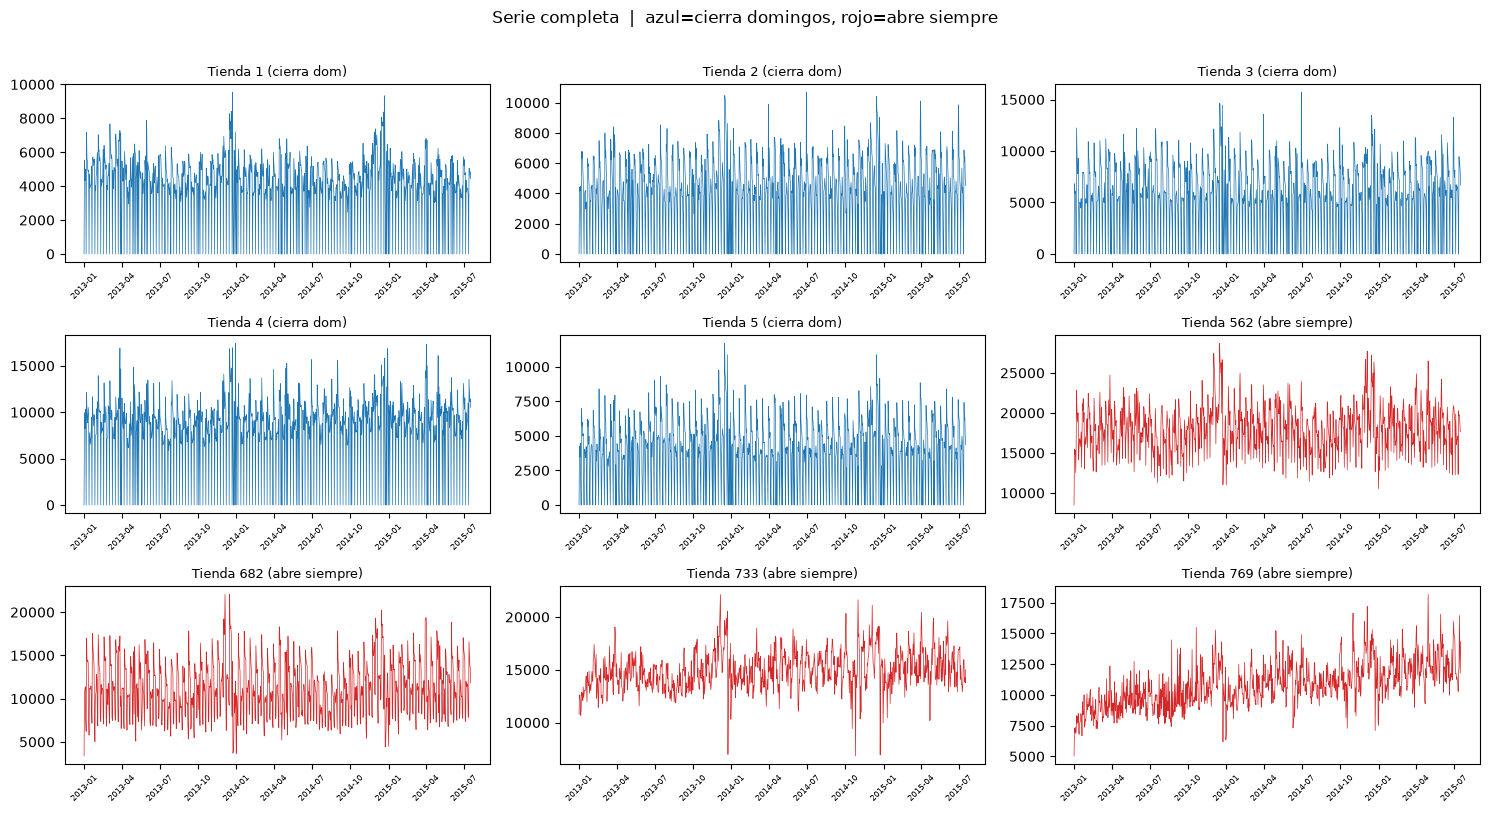

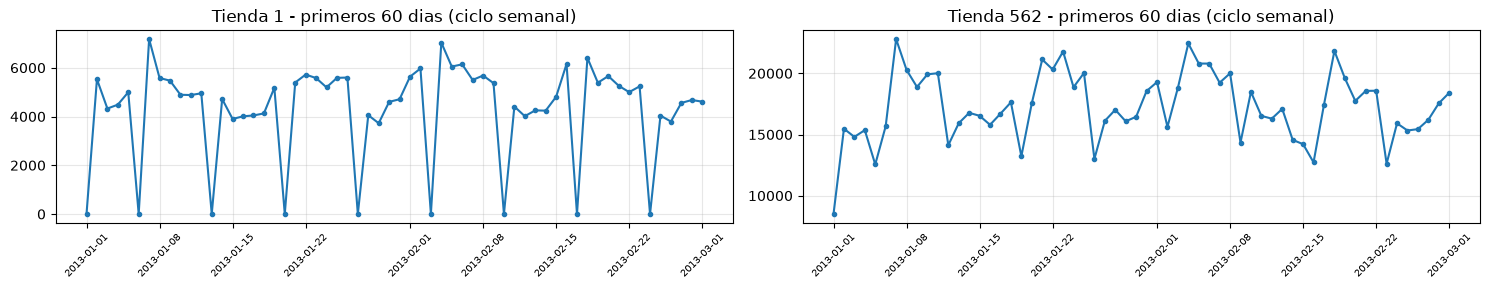

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for ax, sid in zip(axes.flat, TIENDAS):
    g = df[df.Store == sid]
    color = 'tab:blue' if sid in TIENDAS_CIERRAN else 'tab:red'
    ax.plot(g.Date, g.Sales, lw=0.5, color=color)
    fam = 'cierra dom' if sid in TIENDAS_CIERRAN else 'abre siempre'
    ax.set_title(f'Tienda {sid} ({fam})', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
plt.suptitle('Serie completa  |  azul=cierra domingos, rojo=abre siempre', y=1.01)
plt.tight_layout(); plt.show()

# Zoom 60 dias: una tienda de cada familia
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
for ax, sid in zip(axes, [1, 562]):
    g = df[df.Store == sid].iloc[:60]
    ax.plot(g.Date, g.Sales, 'o-', ms=3)
    ax.set_title(f'Tienda {sid} - primeros 60 dias (ciclo semanal)')
    ax.tick_params(axis='x', rotation=45, labelsize=7); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 3.3 Distribucion de ventas y transformacion logarítmica

Las ventas presentan **asimetria a la derecha** (cola de días de alto volumen). Aplicar `log1p(Sales)`
reduce esa asimetria y estabiliza el entrenamiento (la red parte de pesos pequenos y predice mejor
magnitudes acotadas). **Decision:** el objetivo del modelo es `y = log1p(Sales)`; al evaluar
des-transformamos con `expm1`. El valor de asimetria se imprime en la propia figura.

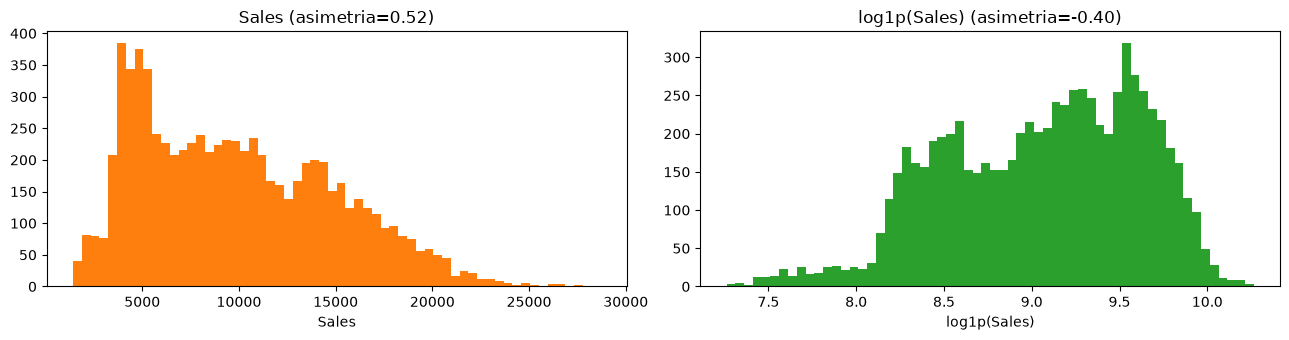

In [6]:
ventas = df[df.Open == 1]['Sales']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].hist(ventas, bins=60, color='tab:orange')
ax[0].set_title(f'Sales (asimetria={ventas.skew():.2f})'); ax[0].set_xlabel('Sales')
ax[1].hist(np.log1p(ventas), bins=60, color='tab:green')
ax[1].set_title(f'log1p(Sales) (asimetria={np.log1p(ventas).skew():.2f})'); ax[1].set_xlabel('log1p(Sales)')
plt.tight_layout(); plt.show()

### 3.4 Estacionalidad y efecto de promociones/festivos

Cuatro vistas en un panel:
- **Dia de la semana**: revela el ciclo semanal (y el cierre dominical de la familia 1).
- **Mes**: ciclo anual (caidas en veráno, picos en diciembre).
- **Promo**: cuanto sube la venta medía con promocion activa.
- **Festivo escolar**: efecto de `SchoolHoliday`.

**Decision:** estas variables de calendario se conocen de antemano -> entran como exógenas/categóricas
(embeddings de `DayOfWeek` y `Month`); `Promo` y `SchoolHoliday` además viajan dentro de la ventana LSTM.

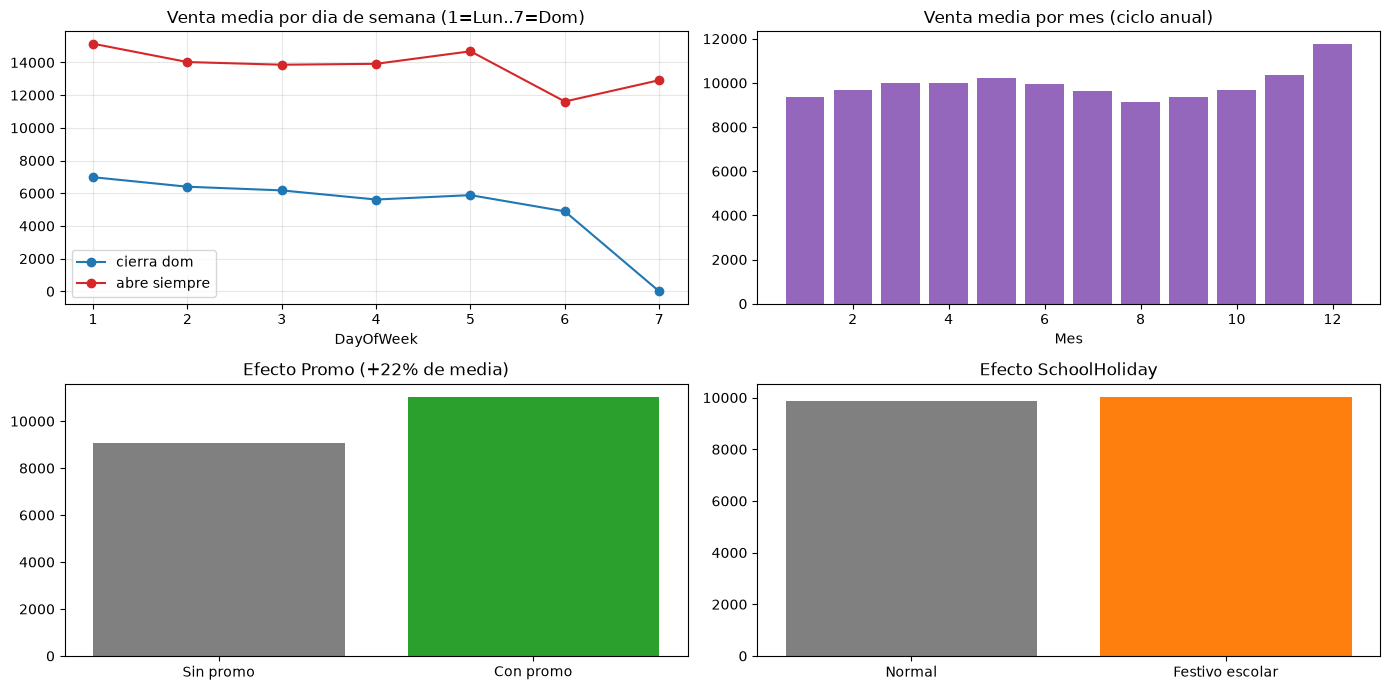

In [7]:
op = df[df.Open == 1]
fig, ax = plt.subplots(2, 2, figsize=(14, 7))

# ventas por dia de semana, por familia
for fam, tiendas, col in [('cierra dom', TIENDAS_CIERRAN, 'tab:blue'),
                          ('abre siempre', TIENDAS_ABIERTAS, 'tab:red')]:
    sub = df[df.Store.isin(tiendas)].groupby('DayOfWeek')['Sales'].mean()
    ax[0,0].plot(sub.index, sub.values, 'o-', label=fam, color=col)
ax[0,0].set_title('Venta media por dia de semana (1=Lun..7=Dom)')
ax[0,0].set_xlabel('DayOfWeek'); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

# ventas por mes
mes = op.groupby('Month')['Sales'].mean()
ax[0,1].bar(mes.index, mes.values, color='tab:purple')
ax[0,1].set_title('Venta media por mes (ciclo anual)'); ax[0,1].set_xlabel('Mes')

# efecto promo
pr = op.groupby('Promo')['Sales'].mean()
ax[1,0].bar(['Sin promo','Con promo'], pr.values, color=['gray','tab:green'])
inc = 100*(pr.get(1,0)-pr.get(0,0))/pr.get(0,1)
ax[1,0].set_title(f'Efecto Promo (+{inc:.0f}% de media)')

# efecto festivo escolar
sh = op.groupby('SchoolHoliday')['Sales'].mean()
ax[1,1].bar(['Normal','Festivo escolar'], [sh.get(0,0), sh.get(1,0)], color=['gray','tab:orange'])
ax[1,1].set_title('Efecto SchoolHoliday')
plt.tight_layout(); plt.show()

### 3.5 Autocorrelacion, heterocedasticidad y la trampa de `Customers`

- **Autocorrelacion (ACF):** picos marcados en multiplos de 7 confirman la estacionalidad semanal y
  justifican los lags `lag_7`, `lag_14` y una ventana `W=28` (cubre 4 semanas).
- **Heterocedasticidad:** la desviacion movil de las ventas no es constante (varia con el nivel), tal como
  comento el profesor; el `log` la atenua.
- **`Customers`:** esta casi perfectamente correlacionada con `Sales`. Usarla seria hacer trampa
  (no se conoce de antemano), por eso el enunciado la **prohibe** como entrada.

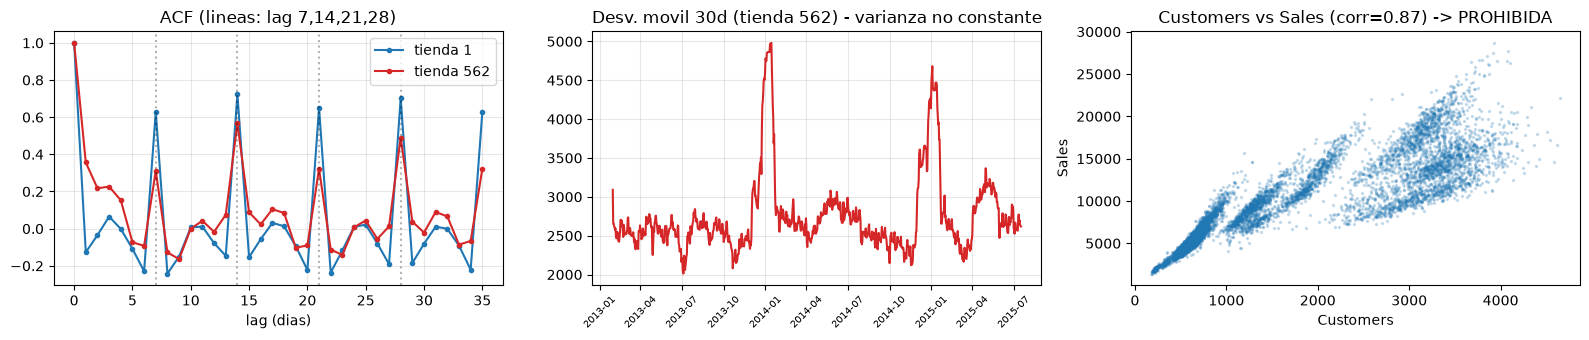

In [8]:
def acf(serie, nlags=35):
    x = np.asarray(serie, dtype=float)
    return [1.0] + [np.corrcoef(x[k:], x[:-k])[0,1] for k in range(1, nlags+1)]

fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))

# ACF para una tienda de cada familia
for sid, col in [(1,'tab:blue'), (562,'tab:red')]:
    serie = df[df.Store == sid].sort_values('Date')['Sales'].values
    a = acf(serie, 35)
    ax[0].plot(range(36), a, 'o-', ms=3, label=f'tienda {sid}', color=col)
for k in [7,14,21,28]:
    ax[0].axvline(k, color='k', ls=':', alpha=.3)
ax[0].set_title('ACF (lineas: lag 7,14,21,28)'); ax[0].set_xlabel('lag (dias)')
ax[0].legend(); ax[0].grid(alpha=.3)

# heterocedasticidad: desviacion movil 30 dias
g = df[df.Store == 562].sort_values('Date')
roll = g['Sales'].rolling(30).std()
ax[1].plot(g['Date'], roll, color='tab:red')
ax[1].set_title('Desv. movil 30d (tienda 562) - varianza no constante')
ax[1].tick_params(axis='x', rotation=45, labelsize=7); ax[1].grid(alpha=.3)

# correlacion Customers vs Sales
corr = df[df.Open==1][['Customers','Sales']].corr().iloc[0,1]
ax[2].scatter(df[df.Open==1]['Customers'], df[df.Open==1]['Sales'], s=2, alpha=.2)
ax[2].set_title(f'Customers vs Sales (corr={corr:.2f}) -> PROHIBIDA')
ax[2].set_xlabel('Customers'); ax[2].set_ylabel('Sales')
plt.tight_layout(); plt.show()

### 3.6 Sintesis: decisiónes de modelado derivadas del EDA

| Hallazgo del EDA | Decision de modelado |
|---|---|
| Ventas muy asimétricas | Objetivo `log1p(Sales)`, des-transformar con `expm1` |
| Fuerte ciclo semanal (ACF en lag 7,14) | Lags `lag_7`/`lag_14` + ventana `W=28` |
| Ciclo anual (veráno/diciembre) | Embedding de `Month` |
| Cierre dominical en familia 1 | Entrenar solo días abiertos; `Open` en la secuencia |
| Promo sube mucho la venta | `Promo` como exogena dentro de la ventana |
| Heterocedasticidad | El `log` estabiliza la varianza |
| `Customers` ~ `Sales` | Excluida (prohibida por el enunciado) |
| Dos familias de tiendas | Justifica la Estrategia B (un modelo por grupo) |

## 4. Split temporal y enventanado

In [9]:
CAT_COLS  = ['Store','StoreType','Assortment','StateHoliday','DayOfWeek','Month']
CAT_IDX   = [c+'_idx' for c in CAT_COLS]
NUM_NAMES = ['Promo','SchoolHoliday','Promo2','CompDistLog',
             'lag7','lag14','mean_w','std_w','promo_w']

# Codificacion categoricas
cat_maps, cat_card = {}, {}
for col in CAT_COLS:
    cats = sorted(df[col].unique())
    cat_maps[col] = {v:i for i,v in enumerate(cats)}
    df[col+'_idx'] = df[col].map(cat_maps[col]).astype(int)
    cat_card[col]  = len(cats)

def construir_ventanas(data):
    seq, ynum, y_out, fecha, store_id, open_t = [], [], [], [], [], []
    cats = {c:[] for c in CAT_IDX}
    for _, g in data.groupby('Store'):
        g  = g.sort_values('Date')
        yv = g['y'].values; pr = g['Promo'].values
        sh = g['SchoolHoliday'].values; op = g['Open'].values
        cd = g['CompDistLog'].values;  p2 = g['Promo2'].values
        cv = {c: g[c].values for c in CAT_IDX}
        for i in range(W, len(g)):
            wy = yv[i-W:i]
            seq.append(np.stack([wy, pr[i-W:i], sh[i-W:i], op[i-W:i]], axis=1))
            ynum.append([pr[i], sh[i], p2[i], cd[i],
                         yv[i-7], yv[i-14], wy.mean(), wy.std(), pr[i-W:i].sum()])
            y_out.append(yv[i]); fecha.append(g['Date'].values[i])
            store_id.append(g['Store'].values[i]); open_t.append(op[i])
            for c in CAT_IDX: cats[c].append(cv[c][i])
    out = {'seq': np.array(seq,'float32'), 'num': np.array(ynum,'float32'),
           'y':   np.array(y_out,'float32'), 'fecha': np.array(fecha),
           'store': np.array(store_id), 'open': np.array(open_t)}
    for c in CAT_IDX: out[c] = np.array(cats[c],'int32')
    return out

ds = construir_ventanas(df)
mask = ds['open'] == 1
for k in list(ds): ds[k] = ds[k][mask]

fechas = ds['fecha']
i_tr = np.where(fechas <  np.datetime64(F_VAL))[0]
i_va = np.where((fechas >= np.datetime64(F_VAL)) & (fechas < np.datetime64(F_TEST)))[0]
i_te = np.where(fechas >= np.datetime64(F_TEST))[0]
print(f'train {len(i_tr)} | val {len(i_va)} | test {len(i_te)}')

esc_seq = StandardScaler().fit(ds['seq'][i_tr][:,:,0].reshape(-1,1))
esc_num = StandardScaler().fit(ds['num'][i_tr])

def escala_seq(s):
    s = s.copy()
    sh = s[:,:,0].shape
    s[:,:,0] = esc_seq.transform(s[:,:,0].reshape(-1,1)).reshape(sh)
    return s.astype('float32')

seq_s = escala_seq(ds['seq'])
num_s = esc_num.transform(ds['num']).astype('float32')

def inputs(idx, filtro_store=None):
    if filtro_store is not None:
        mask_s = np.isin(ds['store'][idx], filtro_store)
        idx = idx[mask_s]
    X = {'seq': seq_s[idx], 'num': num_s[idx]}
    for c in CAT_IDX: X[c] = ds[c][idx]
    return X, ds['y'][idx]

ventas_te  = np.expm1(ds['y'][i_te])
store_te   = ds['store'][i_te]

train 5345 | val 377 | test 1610


## 5. Metricas y baselines

In [10]:
def rmspe(real, pred):
    m = real > 0
    return np.sqrt(np.mean(((real[m]-pred[m])/real[m])**2))

def metricas(real, pred, stores, label=''):
    res = {'R2_global':     round(r2_score(real, pred), 4),
           'RMSPE_global':  round(rmspe(real, pred), 4)}
    for sid in TIENDAS:
        m = stores == sid
        if m.sum() > 0:
            res[f'R2_t{sid}'] = round(r2_score(real[m], pred[m]), 4)
    if label: print(label, res)
    return res

# Baseline 1: persistente a 7 dias
pred_p7 = np.expm1(ds['y'][i_te - 7]) if (i_te - 7).min() >= 0 else None

# Baseline 2: media por (tienda, dia de semana)
inv_dow = {v:k for k,v in cat_maps['DayOfWeek'].items()}
df_tr = df[df.Date < pd.Timestamp(F_TEST)]
media_td = df_tr[df_tr.Open==1].groupby(['Store','DayOfWeek'])['Sales'].mean()
dow_te = np.array([inv_dow[i] for i in ds['DayOfWeek_idx'][i_te]])
pred_base = np.array([media_td.get((s,d), df_tr['Sales'].mean())
                      for s,d in zip(store_te, dow_te)])

resultados = {}
resultados['Baseline (media tienda+dia)'] = metricas(ventas_te, pred_base, store_te,
                                                       'Baseline (media tienda+dia)')
print()
print('R2 por tienda:')
for sid in TIENDAS:
    m = store_te == sid
    if m.sum():
        print(f'  Tienda {sid}: {r2_score(ventas_te[m], pred_base[m]):.3f}')

Baseline (media tienda+dia) {'R2_global': 0.8865, 'RMSPE_global': np.float64(0.187), 'R2_t1': -0.0731, 'R2_t2': 0.4483, 'R2_t3': 0.3749, 'R2_t4': 0.0728, 'R2_t5': 0.5881, 'R2_t562': 0.4466, 'R2_t682': 0.5572, 'R2_t733': 0.0632, 'R2_t769': -1.1901}

R2 por tienda:
  Tienda 1: -0.073
  Tienda 2: 0.448
  Tienda 3: 0.375
  Tienda 4: 0.073
  Tienda 5: 0.588
  Tienda 562: 0.447
  Tienda 682: 0.557
  Tienda 733: 0.063
  Tienda 769: -1.190


---
## ESTRATEGIA A — Un modelo por tienda
**Responsable: Alonso**

se entrena **un modelo independiente por tienda** (9 modelos), el punto de partida que recomienda el
profesor. Con ~550 muestras de train y ~40 de validación por tienda es muy poco dato para una red
recurrente, asi que el foco es **buscar el tamaño adecuado** y medir la **estabilidad** de los resultados.

Probamos **6 variantes**. Tres controlan la **capacidad** (V1/V2/V3a), una la **regularizacion**
(V3b) y dos más permiten comparar **LSTM vs GRU al mismo tamaño** (V4/V5):

| Variante | Recurrente | Entradas | Idea |
|---|---|---|---|
| **V1** | LSTM(32) | todos los embeddings + 9 numéricas | "dar capacidad" |
| **V2** | GRU(12) | embedding `DayOfWeek` + 6 numéricas | tamaño intermedio |
| **V3a** | GRU(8) | igual que V2 | minimizar capacidad |
| **V3b** | GRU(12) + L2(1e-3) | igual que V2, dropout 0.4 | regularizar en vez de encoger |
| **V4** | LSTM(12) | igual que V2 | LSTM vs GRU a igual tamaño |
| **V5** | LSTM(8) | igual que V3a | LSTM vs GRU a igual tamaño |

**Dos salvaguardas metodologicas imprescindibles** con tan poco dato:
1. **Clipping** de la predicción en escala log a `[0, CLIP_MAX]` para que un modelo que diverja no produzca
   ventas astronomicas que arruinen el R2.
2. **Promedíar 3 semillas** (`SEEDS`): los R2 por tienda son muy inestables; reportamos medía y desviacion
   para que el resultado sea reproducible y para *cuantificar* esa inestabilidad.

> Ejecutar 6 variantes x 9 tiendas x 3 semillas tarda ~35 min en CPU. Para una comprobacion rapida usa
> `SEEDS = [7]` (los numeros de la tabla son con las 3 semillas).

In [11]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K

SEEDS    = [7, 17, 42]                    # promediamos varias semillas (inestabilidad). [7] para test rapido
CLIP_MAX = float(df['y'].max()) * 1.05    # tope de la prediccion en escala log (evita explosiones)
NUM_SEL  = [0, 1, 4, 5, 6, 8]             # Promo, SchoolHoliday, lag7, lag14, mean_w, promo_w (para V2/V3)

# ── Definicion de las 4 variantes (modelo + preparacion de inputs) ───────────
def v1():
    si = Input((W, 4), name='seq'); h = LSTM(32)(si)
    ni = Input((len(NUM_NAMES),), name='num'); ramas = [h, Dense(16, activation='relu')(ni)]; ci = []
    for c in CAT_IDX:
        if c == 'Store_idx': continue                       # sin embedding de tienda (modelo individual)
        cc = cat_card[c.replace('_idx','')]; ip = Input((1,), name=c); ci.append(ip)
        ramas.append(Flatten()(Embedding(cc, max(2, cc//2))(ip)))
    x = Dropout(0.3)(Dense(64, activation='relu')(concatenate(ramas)))
    m = Model([si]+ci+[ni], Dense(1)(x)); m.compile(loss='mse', optimizer='adam'); return m

def inp1(idx, sid):
    s = idx[ds['store'][idx] == sid]; X = {'seq': seq_s[s], 'num': num_s[s]}
    for c in CAT_IDX:
        if c != 'Store_idx': X[c] = ds[c][s]
    return X, ds['y'][s]

def _modelo_gru(units, reg=False):
    si = Input((W, 4), name='seq')
    kw = dict(kernel_regularizer=l2(1e-3), recurrent_regularizer=l2(1e-3)) if reg else {}
    h  = GRU(units, **kw)(si)
    di = Input((1,), name='DayOfWeek_idx')
    ereg = dict(embeddings_regularizer=l2(1e-3)) if reg else {}
    e  = Flatten()(Embedding(cat_card['DayOfWeek'], 3, **ereg)(di))
    ni = Input((len(NUM_SEL),), name='num')
    dkw  = dict(kernel_regularizer=l2(1e-3)) if reg else {}
    units_dense = 24 if (reg or units == 12) else 16
    x  = Dropout(0.4 if reg else 0.2)(Dense(units_dense, activation='relu', **dkw)(concatenate([h, e, ni])))
    m  = Model([si, di, ni], Dense(1)(x)); m.compile(loss='mse', optimizer='adam'); return m

v2  = lambda: _modelo_gru(12, reg=False)
v3a = lambda: _modelo_gru(8,  reg=False)
v3b = lambda: _modelo_gru(12, reg=True)

def _modelo_lstm(units):
    si = Input((W, 4), name='seq'); h = LSTM(units)(si)
    di = Input((1,), name='DayOfWeek_idx'); e = Flatten()(Embedding(cat_card['DayOfWeek'], 3)(di))
    ni = Input((len(NUM_SEL),), name='num')
    units_dense = 24 if units == 12 else 16
    x = Dropout(0.2)(Dense(units_dense, activation='relu')(concatenate([h, e, ni])))
    m = Model([si, di, ni], Dense(1)(x)); m.compile(loss='mse', optimizer='adam'); return m

v4 = lambda: _modelo_lstm(12)   # mismo tamaño que V2 (GRU 12) pero con LSTM
v5 = lambda: _modelo_lstm(8)    # mismo tamaño que V3a (GRU 8) pero con LSTM

def inp_gru(idx, sid):
    s = idx[ds['store'][idx] == sid]
    return {'seq': seq_s[s], 'DayOfWeek_idx': ds['DayOfWeek_idx'][s], 'num': num_s[s][:, NUM_SEL]}, ds['y'][s]

# ── Acumuladores de resultados y funcion de entrenamiento ────────────────────
res_global, res_por_tienda, preds_var = {}, {}, {}

def predecir(m, X):
    # Prediccion en euros con doble clip: en log (anti-explosion) y a >= 0
    return np.clip(np.expm1(np.clip(m.predict(X, verbose=0).flatten(), 0, CLIP_MAX)), 0, None)

def entrenar_variante(vname, f_modelo, f_inputs, ep, bs, pat):
    """Entrena un modelo por tienda, promediando SEEDS. Guarda resultados en los dicts globales."""
    r2_seeds = []; por_tienda = {s: [] for s in TIENDAS}; preds_ult = np.zeros(len(i_te))
    for sd in SEEDS:
        preds = np.zeros(len(i_te))
        for sid in TIENDAS:
            K.clear_session()                      # reinicia el grafo -> resultados deterministas
            np.random.seed(sd); tf.random.set_seed(sd)
            X_tr, y_tr_s = f_inputs(i_tr, sid)
            X_va, y_va_s = f_inputs(i_va, sid)
            X_te, y_te_s = f_inputs(i_te, sid)
            m = f_modelo()
            m.fit(X_tr, y_tr_s, validation_data=(X_va, y_va_s), epochs=ep, batch_size=bs, verbose=0,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=pat, restore_best_weights=True)])
            p = predecir(m, X_te); preds[store_te == sid] = p
            por_tienda[sid].append(r2_score(np.expm1(y_te_s), p))
        r2_seeds.append(r2_score(ventas_te, preds)); preds_ult = preds
    res_global[vname]     = (np.mean(r2_seeds), np.std(r2_seeds))
    res_por_tienda[vname] = {s: np.mean(por_tienda[s]) for s in TIENDAS}
    preds_var[vname]      = preds_ult
    print(f'{vname}: R2 global {np.mean(r2_seeds):.3f} +/- {np.std(r2_seeds):.3f}')

### Entrenamiento por arquitectura

Una celda para todas las variantes **LSTM** y otra para todas las **GRU**. Cada bloque puede re-ejecutarse por separado. (`clear_session` + promedíado de semillas reducen la variabilidad, pero los modelos por tienda son intrinsecamente inestables: ver la nota de reproducibilidad en el analisis.)

In [12]:
# ── Variantes LSTM (3 tamaños) — se entrenan las tres aqui (~16 min en CPU) ──
for nombre, fm, fi, hp in [
        ('LSTM(32)+emb', v1,  inp1,    dict(ep=60,  bs=64, pat=8)),
        ('LSTM(12)',     v4,  inp_gru, dict(ep=100, bs=32, pat=12)),
        ('LSTM(8)',      v5,  inp_gru, dict(ep=100, bs=32, pat=12))]:
    entrenar_variante(nombre, fm, fi, **hp)


LSTM(32)+emb: R2 global 0.162 +/- 0.344
LSTM(12): R2 global 0.751 +/- 0.113
LSTM(8): R2 global 0.616 +/- 0.092


In [13]:
# ── Variantes GRU (3 configuraciones) — se entrenan las tres aqui (~18 min en CPU) ──
for nombre, fm, fi, hp in [
        ('GRU(12)',    v2,  inp_gru, dict(ep=100, bs=32, pat=12)),
        ('GRU(8)',     v3a, inp_gru, dict(ep=100, bs=32, pat=12)),
        ('GRU(12)+L2', v3b, inp_gru, dict(ep=100, bs=32, pat=12))]:
    entrenar_variante(nombre, fm, fi, **hp)

NameError: name 'GRU' is not defined

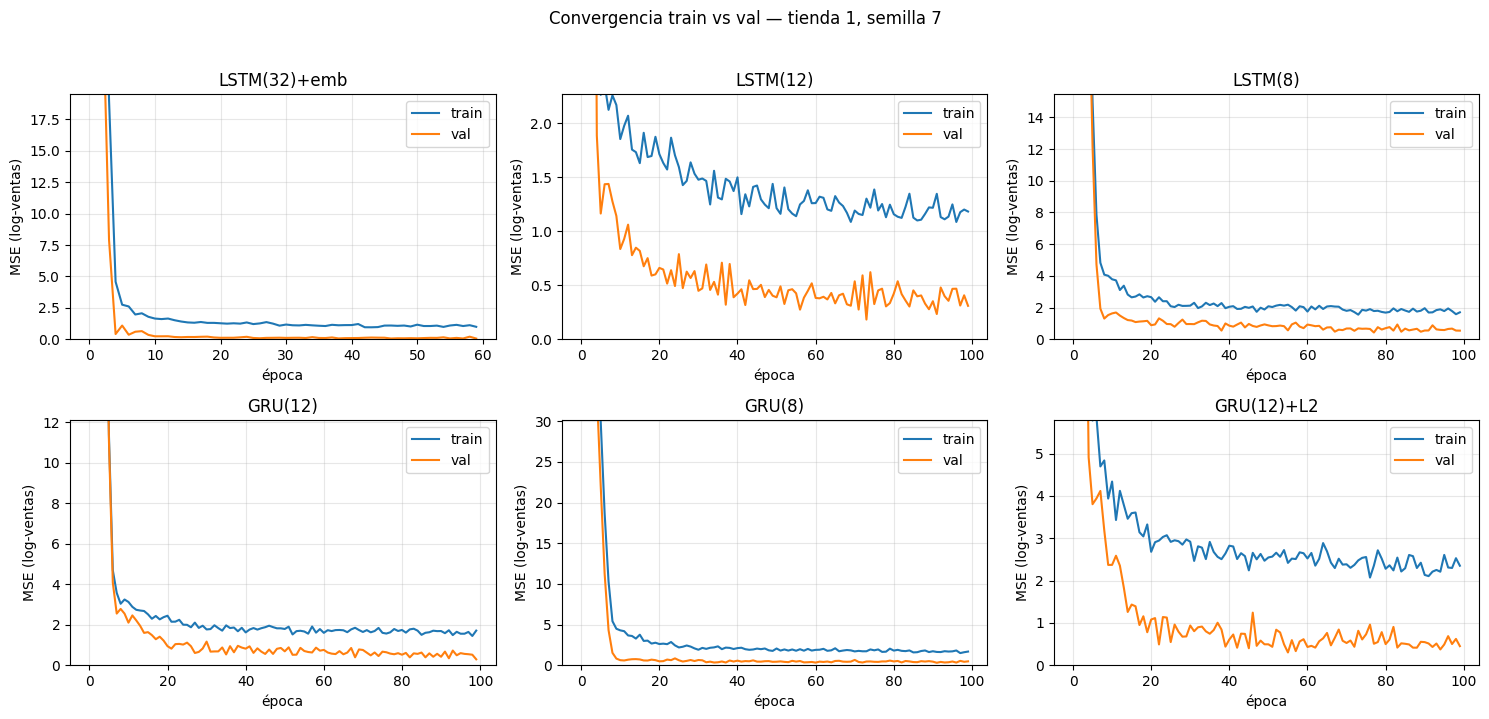

In [ ]:
# ── Curvas de convergencia train vs val de cada arquitectura ─────────────────
from tensorflow.keras import backend as K

TIENDA_CURVA = 1     # tienda a inspeccionar (cámbiala si quieres)
SEED_CURVA   = 7

# (nombre, builder, funcion de inputs, epocas, batch_size)
variantes_curva = [
    ('LSTM(32)+emb', v1,  inp1,    60, 64),
    ('LSTM(12)',     v4,  inp_gru, 100, 32),
    ('LSTM(8)',      v5,  inp_gru, 100, 32),
    ('GRU(12)',      v2,  inp_gru, 100, 32),
    ('GRU(8)',       v3a, inp_gru, 100, 32),
    ('GRU(12)+L2',   v3b, inp_gru, 100, 32),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (nombre, f_modelo, f_inputs, ep, bs) in zip(axes.flat, variantes_curva):
    X_tr, y_tr_s = f_inputs(i_tr, TIENDA_CURVA)
    X_va, y_va_s = f_inputs(i_va, TIENDA_CURVA)
    K.clear_session(); np.random.seed(SEED_CURVA); tf.random.set_seed(SEED_CURVA)
    m = f_modelo()
    h = m.fit(X_tr, y_tr_s, validation_data=(X_va, y_va_s),
              epochs=ep, batch_size=bs, verbose=0)   # sin EarlyStopping: queremos la curva entera
    ax.plot(h.history['loss'],     label='train')
    ax.plot(h.history['val_loss'], label='val')
    ax.set_title(nombre); ax.set_xlabel('época'); ax.set_ylabel('MSE (log-ventas)')
    # recorta el eje Y para que un pico de val no aplaste la grafica
    ax.set_ylim(0, np.percentile(h.history['loss'] + h.history['val_loss'], 95))
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Convergencia train vs val — tienda {TIENDA_CURVA}, semilla {SEED_CURVA}', y=1.02)
plt.tight_layout(); plt.show()

### Comparativa LSTM vs GRU

== R2 global por variante ==
                            arquitectura  R2_global_medio  desv_semillas
LSTM(32)+emb                        LSTM            0.099          0.368
LSTM(12)                            LSTM            0.589          0.319
LSTM(8)                             LSTM            0.720          0.032
GRU(12)                              GRU            0.591          0.219
GRU(8)                               GRU            0.547          0.150
GRU(12)+L2                           GRU            0.204          0.230
Baseline (media tienda+dia)            -            0.886          0.000

== R2 por tienda (media de semillas) ==
     LSTM(32)+emb  LSTM(12)  LSTM(8)  GRU(12)  GRU(8)  GRU(12)+L2  Baseline
1        -163.137   -88.342   -5.298   -3.492 -25.250     -40.525    -0.073
2          -7.658    -2.104   -0.047  -16.887  -2.472     -27.605     0.448
3          -2.349    -0.271   -0.141   -0.006   0.007      -0.328     0.375
4          -0.501    -0.477   -2.441   -5.

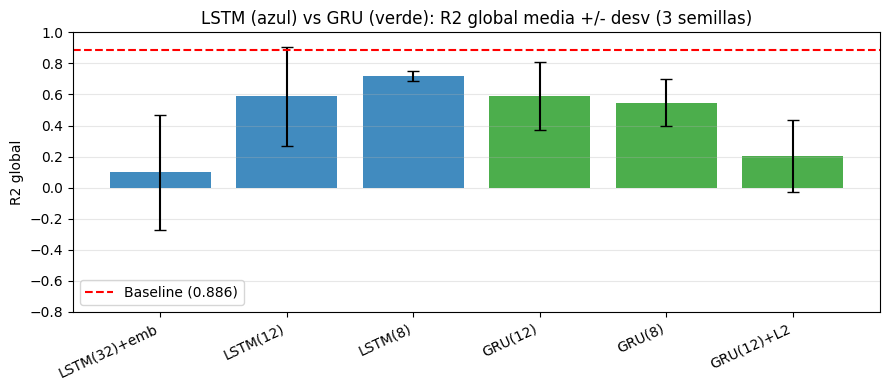


Mejor variante de la Estrategia A: LSTM(8)


,arquitectura,R2_global_medio,desv_semillas
LSTM(32)+emb,LSTM,0.099,0.368
LSTM(12),LSTM,0.589,0.319
LSTM(8),LSTM,0.720,0.032
GRU(12),GRU,0.591,0.219
GRU(8),GRU,0.547,0.150
GRU(12)+L2,GRU,0.204,0.230
Baseline (media tienda+dia),-,0.886,0.000


In [ ]:
# ── Comparativa LSTM vs GRU (ejecutar tras entrenar ambos bloques) ───────────
orden = ['LSTM(32)+emb', 'LSTM(12)', 'LSTM(8)', 'GRU(12)', 'GRU(8)', 'GRU(12)+L2']
r2_base = round(r2_score(ventas_te, pred_base), 3)

tab_glob = pd.DataFrame({'arquitectura':    ['LSTM' if 'LSTM' in k else 'GRU' for k in orden],
                         'R2_global_medio': [round(res_global[k][0], 3) for k in orden],
                         'desv_semillas':   [round(res_global[k][1], 3) for k in orden]}, index=orden)
tab_glob.loc['Baseline (media tienda+dia)'] = ['-', r2_base, 0.0]
print('== R2 global por variante =='); print(tab_glob.to_string())

tab_st = pd.DataFrame({k: res_por_tienda[k] for k in orden}).round(3)
tab_st['Baseline'] = [round(r2_score(ventas_te[store_te == s], pred_base[store_te == s]), 3) for s in TIENDAS]
print('\n== R2 por tienda (media de semillas) =='); print(tab_st.to_string())

# Grafica de barras: media +/- desv, color por arquitectura
medias = [res_global[k][0] for k in orden]; desv = [res_global[k][1] for k in orden]
colores = ['tab:blue' if 'LSTM' in k else 'tab:green' for k in orden]
plt.figure(figsize=(9, 4))
plt.bar(range(len(orden)), medias, yerr=desv, color=colores, capsize=4, alpha=0.85)
plt.axhline(r2_base, color='red', ls='--', label=f'Baseline ({r2_base})')
plt.xticks(range(len(orden)), orden, rotation=25, ha='right')
plt.ylabel('R2 global'); plt.ylim(min(-0.8, min(medias) - 0.1), 1.0)
plt.title('LSTM (azul) vs GRU (verde): R2 global media +/- desv (3 semillas)')
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

# La mejor variante (mayor R2 medio) alimenta la comparativa final entre estrategias
mejor_nombre = max(res_global, key=lambda k: res_global[k][0])
print('\nMejor variante de la Estrategia A:', mejor_nombre)
resultados[f'Estrategia A (por tienda, {mejor_nombre})'] = metricas(ventas_te, preds_var[mejor_nombre], store_te)
tab_glob

### Resultados y justificación (LSTM vs GRU)

1. *LSTM vs GRU: empate técnico. Comparando a igual número de unidades (8 y 12), ninguna arquitectura gana de forma consistente: en unos tamaños va por delante una y en otros la otra, y las diferencias son del orden de la desviación entre semillas. Con estos datos, el tipo de celda recurrente importa menos que el tamaño y el azar de la inicialización.
2. La capacidad pesa más que la arquitectura. El peor modelo, con diferencia, es el más grande (LSTM con muchas unidades y todos los embeddings): además de la peor medía, es el de mayor desviación entre semillas (prácticamente una lotería). Demasiados parámetros para las ~550 muestras de entrenamiento por tienda. Reducir el tamaño y limitar las entradas (embedding de DayOfWeek + lags) es lo que más sube y estabiliza el R².
3. Estabilidad ≠ mejor medía. Las variantes más pequeñas tienden a tener menor desviación entre semillas (son más fiables), aunque no siempre la mejor medía. Es el trade-off sesgo-varianza, visible en las barras de error de la gráfica. Qué variante resulta "la mejor" cambia entre ejecuciones; lo robusto no es el ranking fino, sino que el óptimo está en tamaños pequeños-intermedios.
4. El R² global engaña. Aunque la mejor variante alcanza un R² global aparentemente decente, su R² por tienda es casi siempre negativo. El R² global se infla por las diferencias de nivel entre tiendas (acertar que una tienda vende el triple que otra ya explica mucha varianza agregada); pero dentro de cada tienda los modelos apenas capturan la dinámica. La métrica honesta es el R² por tienda.
5. Ninguna variante bate al baseline. Ni en global ni por tienda: la medía por (tienda, día de la semana) ya captura el nivel y el ciclo semanal, que es casi toda la señal aprovechable con un histórico tan corto.
6. Sobre la reproducibilidad. Aplicamos clipping de la predicción, promedíado de varias semillas y clear_session(). Aun así, los resultados no son reproducibles exactamente: con la misma semilla, los R² cambian entre ejecuciones y entre máquinas. La causa es que la semilla solo fija lo aleatorio (pesos iniciales, barajado), no la aritmética: en CPU, el paralelismo entre hilos y oneDNN reordenan las sumás en coma flotante, y como la suma no es asociativa, aparecen diferencias en los últimos decimales. Normalmente serían irrelevantes, pero estos modelos están tan mal condicionados (al borde de la divergencia con tan pocos datos) que esa diferencia mínima se amplifica hasta cambiar el resultado final. Esa fragilidad extrema es, en sí misma, el resultado principal de esta estrategia.
7. Conclusión. Con ~550 muestras por tienda, el modelo individual no es viable: no supera a un baseline trivial y es frágil hasta a nivel numérico. Esto motiva las Estrategias B (un modelo por grupo) y C (modelo global con embedding de Store), que comparten datos entre tiendas (pooling) para tener suficiente muestra.

In [ ]:

mejor_modelo_A = 'v4' 
pred_A = pd.DataFrame({
    'Date': ds['Date'][i_te],
    'Store': ds['store'][i_te],
    'real': np.expm1(ds['y'][i_te]),
    'pred': preds_var.get(mejor_modelo_A, np.zeros(len(i_te)))
})
pred_A = pred_A.sort_values(['Store', 'Date']).reset_index(drop=True)

In [ ]:
W = 28
CAT_IDX = ['Store_idx', 'StoreType_idx', 'Assortment_idx', 'StateHoliday_idx', 'DayOfWeek_idx', 'Month_idx']
NUM_NAMES = ['Promo', 'SchoolHoliday', 'Promo2', 'CompDistLog', 'lag7', 'lag14', 'mean_w', 'std_w', 'promo_w', 'media_td']


_m_td = df9[(df9.Date < pd.Timestamp('2014-11-15')) & (df9.Open == 1)].groupby(['Store', 'DayOfWeek'])['Sales'].mean()
df9['media_td'] = np.log1p(pd.Series(
    [_m_td.get((s, d), np.nan) for s, d in zip(df9.Store, df9.DayOfWeek)], index=df9.index))
df9['media_td'] = df9['media_td'].fillna(df9['y'].mean())

cat_cols = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek', 'Month']
cat_maps, cat_card = {}, {}
for col in cat_cols:
    cats = sorted(df9[col].unique())
    cat_maps[col] = {v: i for i, v in enumerate(cats)}
    df9[col + '_idx'] = df9[col].map(cat_maps[col]).astype(int)
    cat_card[col] = len(cats)
print('cardinalidades:', cat_card)

cardinalidades: {'Store': 9, 'StoreType': 3, 'Assortment': 3, 'StateHoliday': 4, 'DayOfWeek': 7, 'Month': 12}


Se preparan las dos piezas previas al enventanado: la variable `media_td` (el "conocimiento base" que se
incorpora al objetivo residual) y la codificación de las categóricas a índices enteros, requisito de las
capas `Embedding`. Los mapas se construyen una vez sobre las 9 tiendas y se comparten entre estrategias
para que los índices sean coherentes.

In [ ]:
def construir_ventanas(data, W):
    seq, ynum, y_out, media, fecha, store_id, open_t = [], [], [], [], [], [], []
    cats = {ccol: [] for ccol in CAT_IDX}
    for _, g in data.groupby('Store'):
        g = g.sort_values('Date')
        yv = g['y'].values; pr = g['Promo'].values; sh = g['SchoolHoliday'].values; op = g['Open'].values
        cd = g['CompDistLog'].values; p2 = g['Promo2'].values; mt = g['media_td'].values
        cat_v = {ccol: g[ccol].values for ccol in CAT_IDX}
        for i in range(W, len(g)):
            wy = yv[i - W:i]
            seq.append(np.stack([wy, pr[i - W:i], sh[i - W:i], op[i - W:i]], axis=1))
            ynum.append([pr[i], sh[i], p2[i], cd[i], yv[i - 7], yv[i - 14],
                         wy.mean(), wy.std(), pr[i - W:i].sum(), mt[i]])
            y_out.append(yv[i] - mt[i])   # objetivo: residuo log respecto a la media (tienda, dia)
            media.append(mt[i]); fecha.append(g['Date'].values[i])
            store_id.append(g['Store'].values[i]); open_t.append(op[i])
            for ccol in CAT_IDX:
                cats[ccol].append(cat_v[ccol][i])
    out = {'seq': np.array(seq, dtype='float32'),
           'num': np.array(ynum, dtype='float32'),
           'y': np.array(y_out, dtype='float32'), 'media': np.array(media, dtype='float32'),
           'fecha': np.array(fecha), 'store': np.array(store_id), 'open': np.array(open_t)}
    for ccol in CAT_IDX:
        out[ccol] = np.array(cats[ccol], dtype='int32')
    return out

La función recorre cada tienda por separado y para cada día objetivo construye los tres bloques de
entrada: la secuencia de 28x4 para la parte recurrente, el vector de numéricas del día y las categóricas.
El objetivo que se guarda es ya el residuo respecto a `media_td`.

In [ ]:
F_TEST = np.datetime64('2015-01-01'); F_VAL = np.datetime64('2014-11-15')

def preparar_conjunto(tiendas):
    """Enventana las tiendas indicadas, filtra dias cerrados, particiona y escala (solo con train)."""
    ds = construir_ventanas(df9[df9.Store.isin(tiendas)], W)
    mask = ds['open'] == 1
    for k in list(ds.keys()):
        ds[k] = ds[k][mask]
    fechas = ds['fecha']
    idx = {'tr': np.where(fechas < F_VAL)[0],
           'va': np.where((fechas >= F_VAL) & (fechas < F_TEST))[0],
           'te': np.where(fechas >= F_TEST)[0]}
    esc_seq = StandardScaler().fit(ds['seq'][idx['tr']][:, :, 0].reshape(-1, 1))
    esc_num = StandardScaler().fit(ds['num'][idx['tr']])
    seq_s = ds['seq'].copy()
    sh = seq_s[:, :, 0].shape
    seq_s[:, :, 0] = esc_seq.transform(seq_s[:, :, 0].reshape(-1, 1)).reshape(sh)
    num_s = esc_num.transform(ds['num']).astype('float32')
    def inputs(i):
        X = {'seq': seq_s[i].astype('float32'), 'num': num_s[i]}
        for ccol in CAT_IDX:
            X[ccol] = ds[ccol][i]
        return X
    return ds, idx, inputs

def construir_modelo(u1=64, u2=32, dropout=0.3, dim_emb=10, dense=128):
    seq_in = Input(shape=(W, 4), name='seq')
    h = LSTM(u1, return_sequences=True)(seq_in)
    h = LSTM(u2)(h)
    ramas = [h]; cat_inputs = []
    for ccol in CAT_IDX:
        card = cat_card[ccol.replace('_idx', '')]
        d = int(min(dim_emb, max(2, card // 2)))
        inp = Input(shape=(1,), name=ccol)
        cat_inputs.append(inp)
        ramas.append(Flatten()(Embedding(card, d)(inp)))
    num_in = Input(shape=(len(NUM_NAMES),), name='num')
    ramas.append(Dense(32, activation='relu')(num_in))
    x = concatenate(ramas)
    x = Dense(dense, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(dense // 2, activation='relu')(x)
    out = Dense(1)(x)
    model = Model(inputs=[seq_in] + cat_inputs + [num_in], outputs=out)
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

def rmspe(real, pred):
    m = real > 0
    return np.sqrt(np.mean(((real[m] - pred[m]) / real[m]) ** 2))

os.makedirs('models', exist_ok=True)   # los pesos entrenados se guardan aparte (excluidos del repo)

def entrenar_una(inputs, ds, idx, cfg, seed, nombre, batch=128):
    tf.random.set_seed(seed); np.random.seed(seed)
    model = construir_modelo(**cfg)
    cbs = [ModelCheckpoint(os.path.join('models', nombre + '.keras'), monitor='val_loss', save_best_only=True),
           EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h = model.fit(inputs(idx['tr']), ds['y'][idx['tr']],
                  validation_data=(inputs(idx['va']), ds['y'][idx['va']]),
                  epochs=100, batch_size=batch, verbose=0, callbacks=cbs)
    return model, min(h.history['val_loss'])

def predecir_test(model_o_modelos, inputs, ds, idx):
    """Promedia las predicciones (en log) si se pasa una lista de modelos y deshace el residuo."""
    modelos = model_o_modelos if isinstance(model_o_modelos, list) else [model_o_modelos]
    preds_log = [m.predict(inputs(idx['te']), verbose=0).flatten() for m in modelos]
    media_te = ds['media'][idx['te']]
    pred = np.clip(np.expm1(np.mean(preds_log, axis=0) + media_te), 0, None)
    real = np.expm1(ds['y'][idx['te']] + media_te)
    return pd.DataFrame({'Store': ds['store'][idx['te']], 'Date': ds['fecha'][idx['te']],
                         'real': real, 'pred': pred})

Se define la maquinaria común a todas las estrategias: `preparar_conjunto` enventana y escala cualquier
subconjunto de tiendas (sirve igual para 1 tienda, un grupo o las 9), `construir_modelo` es una plantilla
única de red (LSTM apilada + un embedding por categórica + bloque denso para las numéricas) cuyo tamaño se
controla por parámetros, y `entrenar_una` encapsula el entrenamiento con *early stopping* sobre la
validación. Que las estrategias compartan plantilla garantiza que lo que se compara es la **organización**
de los modelos (por tienda, por grupo) y no arquitecturas incomparables. Para las tiendas individuales los
embeddings de `Store`, `StoreType` o `Assortment` degeneran en constantes, lo cual es inocuo: aportan un
sesgo fijo y el resto de la red hace el trabajo.

## 6. Estrategia B: un modelo por grupo

El análisis de la sección 3 muestra dos familias estructuralmente distintas. Esta estrategia entrena un
modelo para cada una: cada red trabaja con una población homogénea en régimen de apertura y comparte
información entre tiendas parecidas a través del embedding de `Store`. Para cada grupo se procede en dos
pasos:

1. **Selección**: se entrenan dos configuraciónes (una ligera y otra con más capacidad) y se elige la de
   menor pérdida de validación, sin tocar el test.
2. **Ensemble**: con la configuración ganadora se entrenan dos redes con semillas distintas y se
   promedían sus predicciónes en escala log, lo que reduce la varianza típica de redes pequeñas
   entrenadas con pocos datos.

In [ ]:
CONFIGS = [
    dict(u1=64, u2=32, dropout=0.3, dim_emb=10, dense=128),
    dict(u1=96, u2=48, dropout=0.2, dim_emb=16, dense=256),
]
SEEDS_ENSEMBLE = [7, 21]

resultados_B, seleccion, pred_B = {}, [], []
for nombre, tiendas in GRUPOS.items():
    print(f'===== Grupo {nombre}: tiendas {tiendas} =====')
    ds_g, idx_g, in_g = preparar_conjunto(tiendas)
    print('muestras train/val/test:', len(idx_g['tr']), len(idx_g['va']), len(idx_g['te']))

    # 1) seleccion de configuracion por perdida de validacion
    val_por_cfg = []
    for k, cfg in enumerate(CONFIGS):
        _, vl = entrenar_una(in_g, ds_g, idx_g, cfg, SEED, f'B_sel_{nombre[0]}_{k}')
        val_por_cfg.append(vl)
        print(f'  config {k} {cfg} -> val_loss {vl:.4f}')
    k_best = int(np.argmin(val_por_cfg))
    seleccion.append({'Grupo': nombre, 'config': k_best, **CONFIGS[k_best],
                      'val_loss': round(val_por_cfg[k_best], 4)})

    # 2) ensemble de semillas con la configuracion ganadora
    modelos = [entrenar_una(in_g, ds_g, idx_g, CONFIGS[k_best], s, f'B_{nombre[0]}_s{s}')[0]
               for s in SEEDS_ENSEMBLE]
    p = predecir_test(modelos, in_g, ds_g, idx_g)
    pred_B.append(p)
    resultados_B[nombre] = {'R2': r2_score(p.real, p.pred), 'RMSPE': rmspe(p.real.values, p.pred.values)}
    print(nombre, '->', {k: round(v, 4) for k, v in resultados_B[nombre].items()})

pred_B = pd.concat(pred_B, ignore_index=True)
pd.DataFrame(seleccion)

===== Grupo D (cierran domingos): tiendas [1, 2, 3, 4, 5] =====
muestras train/val/test: 2725 189 818
  config 0 {'u1': 64, 'u2': 32, 'dropout': 0.3, 'dim_emb': 10, 'dense': 128} -> val_loss 0.0530
  config 1 {'u1': 96, 'u2': 48, 'dropout': 0.2, 'dim_emb': 16, 'dense': 256} -> val_loss 0.0478
D (cierran domingos) -> {'R2': 0.8866, 'RMSPE': np.float32(0.12)}
===== Grupo N (abre siempre): tiendas [562, 682, 733, 769] =====
muestras train/val/test: 2620 188 792
  config 0 {'u1': 64, 'u2': 32, 'dropout': 0.3, 'dim_emb': 10, 'dense': 128} -> val_loss 0.0252
  config 1 {'u1': 96, 'u2': 48, 'dropout': 0.2, 'dim_emb': 16, 'dense': 256} -> val_loss 0.0224
N (abre siempre) -> {'R2': 0.8551, 'RMSPE': np.float32(0.0897)}


,Grupo,config,u1,u2,dropout,dim_emb,dense,val_loss
0,D (cierran domingos),1,96,48,0.2,16,256,0.0478
1,N (abre siempre),1,96,48,0.2,16,256,0.0224


Se entrena el pipeline completo para cada grupo. La tabla recoge la configuración ganadora según la
pérdida de validación; las métricas impresas por grupo corresponden ya al ensemble de dos semillas. La
selección puede diferir entre grupos, lo que respalda la idea de calibrar cada familia por separado en
lugar de imponer una única arquitectura.

## ⚠️ **IMPORTANTE:** Para CLAUDE... Crea graficas como en la estrategia A:) 

## 7. Estrategia C: un modelo global

**[AQUÍ DEBE IR LA PARTE DE PIETTRO]**
Hay que pegar aquí el código para entrenar un único modelo global utilizando todas las tiendas a la vez y la mejor configuración de hiperparámetros encontrada.

> ⚠️ **IMPORTANTE:** Cuando se añada la Estrategia C, hay que acordarse de actualizar la **Comparativa final** (la sección de abajo) para que la tabla y las gráficas incluyan también los resultados de la Estrategia C (`pred_C`) y se puedan comparar las tres a la vez.

## 8. Comparativa final

Como referencia se usa el baseline clásico de este problema: la medía de ventas por (tienda, día de la
semana) calculada con datos anteriores al test. Es un baseline exigente porque la estacionalidad semanal
explica la mayor parte de la varianza; superar este listón es la prueba de que una red aporta valor
real.

In [ ]:
df_tr_open = df9[(df9.Date < pd.Timestamp(F_TEST)) & (df9.Open == 1)]
media_base = df_tr_open.groupby(['Store', 'DayOfWeek'])['Sales'].mean()
for p in (pred_A, pred_B):
    dow = pd.to_datetime(p['Date']).dt.dayofweek + 1
    p['base'] = [media_base.get((s, d), df_tr_open['Sales'].mean()) for s, d in zip(p.Store, dow)]

tabla_final = pd.DataFrame([
    {'Modelo': 'Baseline media (tienda, dia)',
     'R2_9tiendas': r2_score(pred_A.real, pred_A.base),
     'RMSPE_9tiendas': rmspe(pred_A.real.values, pred_A.base.values)},
    {'Modelo': 'A - Un modelo por tienda (9 modelos)',
     'R2_9tiendas': r2_score(pred_A.real, pred_A.pred),
     'RMSPE_9tiendas': rmspe(pred_A.real.values, pred_A.pred.values)},
    {'Modelo': 'B - Un modelo por grupo (2 modelos, ensemble)',
     'R2_9tiendas': r2_score(pred_B.real, pred_B.pred),
     'RMSPE_9tiendas': rmspe(pred_B.real.values, pred_B.pred.values)},
]).round(4)
tabla_final

,Modelo,R2_9tiendas,RMSPE_9tiendas
0,"Baseline media (tienda, dia)",0.8865,0.1870
1,A - Un modelo por tienda (9 modelos),0.9457,0.1116
2,"B - Un modelo por grupo (2 modelos, ensemble)",0.9511,0.1062


Se evalúan las dos estrategias y el baseline sobre exactamente las mismás Observaciones de test (mismos
días, mismás tiendas), de modo que la tabla es directamente comparable. La lectura detallada se hace tras
el desglose por tienda.

In [ ]:
comp_tienda = pd.DataFrame({
    'R2_A': pred_A.groupby('Store').apply(lambda g: r2_score(g.real, g.pred), include_groups=False),
    'R2_B': pred_B.groupby('Store').apply(lambda g: r2_score(g.real, g.pred), include_groups=False),
    'RMSPE_A': pred_A.groupby('Store').apply(lambda g: rmspe(g.real.values, g.pred.values), include_groups=False),
    'RMSPE_B': pred_B.groupby('Store').apply(lambda g: rmspe(g.real.values, g.pred.values), include_groups=False),
})
comp_tienda['Grupo'] = ['D' if s in GRUPO_D else 'N' for s in comp_tienda.index]
comp_tienda.round(4)

,R2_A,R2_B,RMSPE_A,RMSPE_B,Grupo
Store,,,,,
1,0.4801,0.4277,0.1324,0.1352,D
2,0.8088,0.8216,0.1153,0.1142,D
3,0.8186,0.8018,0.1171,0.1194,D
4,0.4564,0.4513,0.1151,0.1101,D
5,0.8507,0.8685,0.1344,0.1197,D
562,0.6342,0.7482,0.0890,0.0711,N
682,0.8833,0.8648,0.0890,0.0926,N
733,0.2498,0.3925,0.0987,0.0853,N
769,0.0842,0.1236,0.1144,0.1062,N


El desglose tienda a tienda permite ver donde gana cada estrategia y matiza la foto global. Conviene
recordar la diferencia entre métricas: el R² mide la varianza explicada, de modo que en tiendas de serie
muy plana (típicamente las que abren todos los días) puede ser bajo aunque el error relativo sea pequeno;
el RMSPE mide ese error relativo y es más estable e interpretable tienda a tienda. Por eso se reportan
ambos.

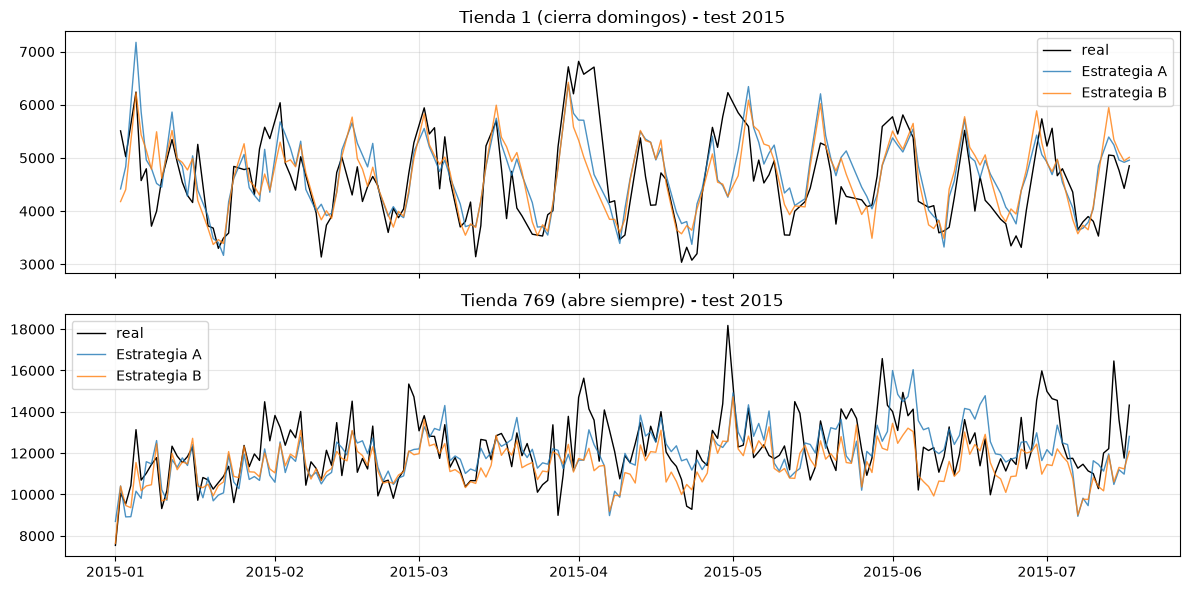

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, s in zip(axes, [1, 769]):
    gA = pred_A[pred_A.Store == s].sort_values('Date')
    gB = pred_B[pred_B.Store == s].sort_values('Date')
    ax.plot(pd.to_datetime(gA.Date), gA.real, label='real', lw=1, color='black')
    ax.plot(pd.to_datetime(gA.Date), gA.pred, label='Estrategia A', lw=1, alpha=0.8)
    ax.plot(pd.to_datetime(gB.Date), gB.pred, label='Estrategia B', lw=1, alpha=0.8)
    ax.set_title(f"Tienda {s} ({'cierra domingos' if s in GRUPO_D else 'abre siempre'}) - test 2015")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Se representan las predicciónes de ambas estrategias frente al valor real en el test para una tienda de cada familia. En la tienda 1 se aprecia cómo ambas reproducen el patrón semanal y los picos de promoción; en la tienda 769, de serie más plana, las diferencias entre estrategias se concentran en el ajuste fino del nivel día a día.

## 9. Reflexión final

- **La decisión de mayor impacto no fue la arquitectura sino el objetivo.** Prediciendo `log(1+Sales)`
  directamente, los modelos quedaban por debajo del baseline de medías: les costaba fijar el nivel de
  cada tienda. Reformular el objetivo como residuo respecto a la medía (tienda, día de la semana)
  incorpora el baseline dentro del modelo y deja que la red aprenda solo las desviaciones (promociones,
  festivos, dinámica reciente). Con pocos datos, dar al modelo el punto de partida correcto vale más que
  añadir capas.

- **Especialización frente a datos.** Las dos estrategias ocupan puntos distintos del espectro: A maximiza
  la especialización (cada serie tiene su red) al precio de entrenar con muy pocos datos por modelo y de
  no poder transferir patrónes comúnes; B agrupa tiendas estructuralmente parecidas, gana datos por
  modelo y mantiene la identidad de cada tienda vía embedding. La comparativa de la sección 8 cuantifica
  ese intercambio sobre el mismo test.

- **R² frente a RMSPE.** El R² agregado favorece a quien acierta en las tiendas de mayor varianza; el
  RMSPE mide el error relativo y es más justo tienda a tienda. Las tiendas que abren siempre obtienen
  RMSPE excelentes con R² individuales bajos porque su serie apenas tiene varianza que explicar: un R²
  por tienda bajo no debe leerse como mal ajuste sin mirar el error relativo.

- **Líneas de mejora.** Búsqueda de hiperparámetros más amplia e independiente por estrategia, más
  semillas en los ensembles, calendario de festivos regional alemán como exógena adicional, y la
  extensión natural del espectro: el modelo global con las 1.115 tiendas y embedding de `Store`, que
  permitiría además inicializar los modelos especializados por *fine-tuning*.